# Capstone Phase 3C — Room for Improvement: DA-HGNN-E (ensemble)
**M A Kaushik · CH.SC.U4CSE24123 · PSID 181**
Prerequisites: Phase 3A (LM scores) and Phase 3B (embeddings, graphs and cached DA-HGNN / MLP runs).

### Why a Phase 3C
Phase 3B's DA-HGNN-F beat the paper on all three datasets. It was **not** uniformly the best few-label method, though: a supervised MLP won on TEC, and the calibrated teacher tied on GoEmotions. Also, on held-out data the three models disagree a lot. On 78% of posts at least one of them is right, against 68% for v1. This notebook asks how much of that headroom can be recovered.

### Protocol (no test-set tuning)
* All candidates are judged on the **held-out pool**: the gold-labelled pool posts that were *not* among the 500 training labels (GoEmotions ≈ 5.8k, Friends ≈ 1.8k, TEC ≈ 3.7k per seed). The 80% test split is not touched in Sections 2–4.
* **Selection rule, fixed before evaluation:** the candidate with the highest mean of (total accuracy + weighted F1)/2 over the three datasets, averaged over 5 seeds. Ties go to fewer members.
* The selected model is evaluated **once** on the test split (Section 5).

### New ingredient: fine-tuning the LMs on the same 500 labels
This is a baseline any reviewer will ask for, and a strong, diverse ensemble member. **RoBERTa-large** is fine-tuned with **LoRA** (r = 16 on the query/key/value projections; Hu et al., 2022) because full fine-tuning does not fit a 6 GB GPU. **DistilRoBERTa** is fully fine-tuned. Both use 80% of the 500 labels for training and 20% for early stopping (the same split as DA-HGNN), and predict only the dataset's own classes.

## 1. Shared pipeline (identical to Phase 3B)
Data, features, graph, the DA-HGNN model, the decision layer and the evaluation helpers are reused unchanged. Cached 3B runs are loaded, not retrained.

In [1]:
import os, sys, re, json, html, random, time, itertools, warnings, subprocess
from collections import Counter, defaultdict

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'torch_geometric'], check=True)
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/Capstone Project'   # change if the folder is elsewhere in Drive
else:
    PROJECT_DIR = os.getcwd()

PROC_DIR = os.path.join(PROJECT_DIR, 'data', 'processed')
REP_DIR = os.path.join(PROJECT_DIR, 'results', 'replication')
RES_DIR = os.path.join(PROJECT_DIR, 'results', 'improved')
RUN_DIR = os.path.join(RES_DIR, 'runs')            # cached predictions of every trained model (lets re-runs resume)
for d in (RES_DIR, RUN_DIR):
    os.makedirs(d, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import scipy.sparse as sp
from scipy import stats
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import scatter
from transformers import AutoTokenizer, AutoModel
from transformers.utils import logging as hf_logging
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Project dir:', PROJECT_DIR)
print('Device     :', DEVICE, torch.cuda.get_device_name(0) if DEVICE == 'cuda' else '')

C:\Users\kaush\venvs\capstone\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Project dir: C:\Users\kaush\OneDrive\ドキュメント\College\ML\Capstone Project
Device     : cuda NVIDIA GeForce RTX 2060


In [2]:
CFG = dict(
    lms={'distil': 'j-hartmann/emotion-english-distilroberta-base', 'roberta': 'j-hartmann/emotion-english-roberta-large'},
    labels=['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise'],
    datasets=['GoEmotions', 'Friends', 'TEC'],
    pool_frac=0.2, split_seed=42,            # 20% labelled pool (dev) / 80% untouched test
    n_labels=500,                            # Setting B label budget per dataset
    top_k_phrases=4, textrank_window=3, edge_mean=0.5, edge_std=0.1,   # paper's phrase rules
    knn_k=10,                                # semantic tweet-tweet neighbours
    hidden=256, layers=2, dropout=0.3, attn_size=64,
    lr=2e-3, weight_decay=1e-4, epochs=200, patience=25,
    mask_p=0.3,                              # score-masking (disagreement simulation) rate
    fusion_w=0.5,                            # weight of DA-HGNN vs calibrated teacher in the final decision
    smooth_alpha=0.5, smooth_iters=10,
    seeds=[0, 1, 2, 3, 4], ablation_seeds=[0, 1, 2],
    budgets=[50, 100, 200, 500, 1000, 2000], budget_seeds=[0, 1, 2],
)
LABELS = CFG['labels']; L2I = {l: i for i, l in enumerate(LABELS)}; N_CLS = len(LABELS); NEU = L2I['neutral']
COLS = {m: [f'{m}_{l}' for l in LABELS] for m in ('distil', 'roberta', 'distil_v2')}

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)

In [3]:
DATA = {}
for n in CFG['datasets']:
    p = os.path.join(PROC_DIR, f'{n.lower()}_scored.csv')
    if not os.path.exists(p):
        raise FileNotFoundError(f'{p} not found — run Capstone_Phase3A_Paper_Replication.ipynb first.')
    d = pd.read_csv(p, keep_default_na=False)
    pool, _ = train_test_split(np.arange(len(d)), train_size=CFG['pool_frac'], random_state=CFG['split_seed'], stratify=d['gold'])
    d['split'] = 'test'; d.loc[pool, 'split'] = 'pool'
    DATA[n] = d
summary = pd.DataFrame({n: {'posts': len(d), 'pool (labelled candidates)': (d.split == 'pool').sum(), 'test (80%)': (d.split == 'test').sum(),
                            'classes in taxonomy': d.gold.nunique(), f'N = {CFG["n_labels"]} labels = % of data': round(100 * CFG['n_labels'] / len(d), 1)}
                        for n, d in DATA.items()}).T
summary

,posts,pool (labelled candidates),test (80%),classes in taxonomy,N = 500 labels = % of data
GoEmotions,31621.0,6324.0,25297.0,7.0,1.6
Friends,11731.0,2346.0,9385.0,7.0,4.3
TEC,21051.0,4210.0,16841.0,6.0,2.4


In [4]:
def embed(model_name, texts, bs=64):
    tok = AutoTokenizer.from_pretrained(model_name)
    m = AutoModel.from_pretrained(model_name).to(DEVICE).eval()
    if DEVICE == 'cuda': m = m.half()
    idx = np.argsort([len(t) for t in texts]); out = np.zeros((len(texts), m.config.hidden_size), np.float16)
    with torch.inference_mode():
        for s in range(0, len(texts), bs):
            b = idx[s:s + bs]
            enc = tok([texts[i] for i in b], padding=True, truncation=True, max_length=128, return_tensors='pt').to(DEVICE)
            h = m(**enc).last_hidden_state.float(); msk = enc['attention_mask'].unsqueeze(-1).float()
            out[b] = ((h * msk).sum(1) / msk.sum(1)).cpu().numpy().astype(np.float16)
    del m
    if DEVICE == 'cuda': torch.cuda.empty_cache()
    return out

def js_div(A, B):
    M = (A + B) / 2
    kl = lambda P, Q: (P * (np.log(P + 1e-9) - np.log(Q + 1e-9))).sum(1)
    return 0.5 * kl(A, M) + 0.5 * kl(B, M)

FEAT = {}
for n, d in DATA.items():
    E = []
    for k, hf in CFG['lms'].items():
        f = os.path.join(PROC_DIR, f'{n.lower()}_emb_{k}.npy')
        if not os.path.exists(f):
            print(f'{n}: embedding with {hf} ...'); np.save(f, embed(hf, d['clean'].tolist()))
        E.append(np.load(f).astype(np.float32))
    E = np.hstack(E); E = (E - E.mean(0)) / (E.std(0) + 1e-6)
    A = d[COLS['distil']].values.astype(np.float32); B = d[COLS['roberta']].values.astype(np.float32); M = (A + B) / 2
    desc = np.stack([A.max(1), B.max(1), -(M * np.log(M + 1e-9)).sum(1) / np.log(N_CLS), js_div(A, B)], 1).astype(np.float32)
    FEAT[n] = dict(A=A, B=B, M=M, V2=d[COLS['distil_v2']].values.astype(np.float32), desc=desc, E=E.astype(np.float32),
                   la=A.argmax(1), lb=B.argmax(1), comp=A.argmax(1) == B.argmax(1), gold=d['gold'].map(L2I).values,
                   test=(d['split'] == 'test').values, pool=np.where(d['split'] == 'pool')[0],
                   allowed=np.array([l in set(d['gold']) for l in LABELS]))
    print(f'{n:10s} embeddings {E.shape}  agreed {FEAT[n]["comp"].mean():.1%}  classes allowed: {[l for l, a in zip(LABELS, FEAT[n]["allowed"]) if a]}')

GoEmotions embeddings (31621, 1792)  agreed 72.7%  classes allowed: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']


Friends    embeddings (11731, 1792)  agreed 72.1%  classes allowed: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']


TEC        embeddings (21051, 1792)  agreed 67.1%  classes allowed: ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']


In [5]:
STOP = set(ENGLISH_STOP_WORDS) | {"i'm", "it's", "that's", "you're", "i've", "i'll", "he's", "she's", "they're", "we're",
                                  "there's", "what's", "let's", "i'd", "you'll", "you've", "we've", "they've", 'im', 'dont', 'thats', 'youre'}
TOKEN_RE = re.compile(r"[a-z][a-z']+")

def textrank_phrases(text, top_k=CFG['top_k_phrases'], window=CFG['textrank_window']):
    words = [w.strip("'") for w in TOKEN_RE.findall(text.lower())]
    cands = [w for w in words if w not in STOP and len(w) > 2]
    if not cands:
        return []
    g = nx.Graph(); g.add_nodes_from(cands)
    for i in range(len(cands)):
        for j in range(i + 1, min(i + window, len(cands))):
            if cands[i] != cands[j]:
                g.add_edge(cands[i], cands[j])
    rank = nx.pagerank(g) if g.number_of_edges() else {w: 1.0 for w in g}
    top = set(sorted(rank, key=rank.get, reverse=True)[:top_k])
    phrases, run = set(top), []
    for i, w in enumerate(words):
        if w in top and (not run or i == run[-1][0] + 1):
            run.append((i, w))
        else:
            if len(run) > 1: phrases.add(' '.join(x for _, x in run))
            run = [(i, w)] if w in top else []
    if len(run) > 1: phrases.add(' '.join(x for _, x in run))
    return sorted(phrases)

def knn_edges(E, k):
    X = F.normalize(torch.tensor(E, device=DEVICE), dim=1); src, dst = [], []
    for s in range(0, len(X), 4096):
        sim = X[s:s + 4096] @ X.T
        sim[torch.arange(sim.shape[0]), torch.arange(s, s + sim.shape[0])] = -1
        src.append(sim.topk(k, dim=1).indices.reshape(-1))
        dst.append(torch.arange(s, s + sim.shape[0], device=DEVICE).repeat_interleave(k))
    return torch.stack([torch.cat(src), torch.cat(dst)])            # neighbour -> tweet

GRAPH = {}
for n, d in DATA.items():
    f = FEAT[n]
    phrases = d['clean'].map(textrank_phrases)
    vocab = sorted({p for ps in phrases for p in ps}); p2i = {p: i for i, p in enumerate(vocab)}
    tp = np.array([(t, p2i[p]) for t, ps in enumerate(phrases) for p in ps]).T
    Mx = sp.csr_matrix((np.ones(tp.shape[1], np.float32), (tp[0], tp[1])), shape=(len(d), len(vocab)))
    Mc = sp.diags(f['comp'].astype(np.float32)) @ Mx
    sup = np.asarray(Mc.sum(0)).ravel(); den = np.maximum(sup, 1)[:, None]
    S = np.hstack([f['A'], f['B']])
    mean = np.asarray(Mc.T @ S) / den; std = np.sqrt(np.clip(np.asarray(Mc.T @ S ** 2) / den - mean ** 2, 0, None))
    cnt = np.maximum(np.asarray(Mx.sum(0)).ravel(), 1)[:, None]
    xp = np.hstack([mean, std, (sup > 0)[:, None], np.asarray(Mx.T @ f['E']) / cnt]).astype(np.float32)
    m7 = np.asarray(Mc.T @ f['M']) / den; s7 = np.sqrt(np.clip(np.asarray(Mc.T @ f['M'] ** 2) / den - m7 ** 2, 0, None))
    pe = (m7 > CFG['edge_mean']) & (s7 < CFG['edge_std']) & (sup[:, None] > 0)
    pe_idx = np.array(np.nonzero(pe))
    t = lambda a: torch.tensor(np.ascontiguousarray(a), dtype=torch.long, device=DEVICE)
    ei = {('tweet', 'has', 'phrase'): t(tp), ('phrase', 'in', 'tweet'): t(tp[::-1]),
          ('phrase', 'signals', 'emotion'): t(pe_idx), ('emotion', 'signalled_by', 'phrase'): t(pe_idx[::-1]),
          ('tweet', 'similar', 'tweet'): knn_edges(f['E'], CFG['knn_k'])}
    GRAPH[n] = dict(phrases=phrases, vocab=vocab, Mx=Mx, pe=pe, ei=ei, xp=torch.tensor(xp, device=DEVICE), xe=torch.eye(N_CLS, device=DEVICE))
    print(f'{n:10s} tweets={len(d):6,d} phrases={len(vocab):6,d} T-P={tp.shape[1]:7,d} P-E={pe_idx.shape[1]:6,d} T-T(kNN)={ei[("tweet","similar","tweet")].shape[1]:7,d} '
          f'phrases without agreed tweet={int((sup == 0).sum()):,} (now have embedding features)')

GoEmotions tweets=31,621 phrases=38,746 T-P=132,152 P-E=22,394 T-T(kNN)=316,210 phrases without agreed tweet=8,736 (now have embedding features)


Friends    tweets=11,731 phrases= 9,439 T-P= 33,292 P-E= 5,155 T-T(kNN)=117,310 phrases without agreed tweet=2,204 (now have embedding features)


TEC        tweets=21,051 phrases=32,838 T-P=102,969 P-E=17,111 T-T(kNN)=210,510 phrases without agreed tweet=9,361 (now have embedding features)


In [6]:
class HeteroGNNConv(nn.Module):                       # paper Eq. (1)-(2)
    def __init__(self, in_src, in_dst, out):
        super().__init__()
        self.lin_dst, self.lin_src, self.lin_update = nn.Linear(in_dst, out), nn.Linear(in_src, out), nn.Linear(2 * out, out)
    def forward(self, x_src, x_dst, ei):
        agg = scatter(x_src[ei[0]], ei[1], dim=0, dim_size=x_dst.size(0), reduce='mean')
        return self.lin_update(torch.cat([self.lin_dst(x_dst), self.lin_src(agg)], dim=-1))

class HeteroLayer(nn.Module):                          # paper Eq. (4)-(5): semantic attention over relations
    def __init__(self, dims, out, edge_types, attn_size):
        super().__init__()
        self.edge_types = edge_types
        self.convs = nn.ModuleDict({'__'.join(et): HeteroGNNConv(dims[et[0]], dims[et[2]], out) for et in edge_types})
        self.attn = nn.ModuleDict({t: nn.Sequential(nn.Linear(out, attn_size), nn.Tanh(), nn.Linear(attn_size, 1, bias=False))
                                   for t in {et[2] for et in edge_types}})
        self.alpha = {}
    def forward(self, x, ei):
        msgs, names = defaultdict(list), defaultdict(list)
        for et in self.edge_types:
            msgs[et[2]].append(self.convs['__'.join(et)](x[et[0]], x[et[2]], ei[et])); names[et[2]].append(f'{et[0]}→{et[2]}')
        out = {}
        for t, hs in msgs.items():
            H = torch.stack(hs, 1)
            if len(hs) > 1:
                a = torch.softmax(self.attn[t](H).mean(0), 0); self.alpha[t] = (names[t], a.detach().view(-1))
                out[t] = (a.unsqueeze(0) * H).sum(1)
            else:
                out[t] = H[:, 0]
        return out

class DAHGNN(nn.Module):
    def __init__(self, d_tweet, d_phrase, edge_types, hidden=CFG['hidden'], layers=CFG['layers'], dropout=CFG['dropout']):
        super().__init__()
        self.proj = nn.ModuleDict({'tweet': nn.Linear(d_tweet, hidden), 'phrase': nn.Linear(d_phrase, hidden), 'emotion': nn.Linear(N_CLS, hidden)})
        self.layers = nn.ModuleList([HeteroLayer({k: hidden for k in self.proj}, hidden, edge_types, CFG['attn_size']) for _ in range(layers)])
        self.norms = nn.ModuleList([nn.ModuleDict({k: nn.LayerNorm(hidden) for k in self.proj}) for _ in range(layers)])
        self.skip, self.cls, self.dropout = nn.Linear(d_tweet, hidden), nn.Linear(2 * hidden, N_CLS), dropout
    def forward(self, x_tweet, g):
        x = {'tweet': self.proj['tweet'](x_tweet), 'phrase': self.proj['phrase'](g['xp']), 'emotion': self.proj['emotion'](g['xe'])}
        x = {k: F.dropout(F.relu(v), self.dropout, self.training) for k, v in x.items()}
        for layer, norm in zip(self.layers, self.norms):
            h = layer(x, g['ei'])
            x = {k: F.dropout(F.relu(norm[k](h.get(k, torch.zeros_like(v)) + v)), self.dropout, self.training) for k, v in x.items()}
        return self.cls(torch.cat([x['tweet'], F.relu(self.skip(x_tweet))], -1))

class MLP(nn.Module):                                  # same features, no graph (ablation / baseline)
    def __init__(self, d_in, hidden=CFG['hidden'], dropout=CFG['dropout']):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_in, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Dropout(dropout), nn.Linear(hidden, N_CLS))
    def forward(self, x, g=None): return self.net(x)


def tweet_input(f, score_mask=None, use_scores=True, use_emb=True, paper_feats=False):
    if paper_feats:                                    # the paper's tweet features: DistilRoBERTa scores only
        return torch.tensor(f['A'], device=DEVICE)
    parts = []
    if use_scores:
        S = np.hstack([f['A'], f['B'], f['desc']])
        m = np.zeros((len(S), 1), np.float32) if score_mask is None else score_mask[:, None].astype(np.float32)
        parts += [S * (1 - m), m]
    if use_emb:
        parts.append(f['E'])
    return torch.tensor(np.hstack(parts), dtype=torch.float32, device=DEVICE)

def run_cached(key, fn):
    path = os.path.join(RUN_DIR, re.sub(r'[^A-Za-z0-9_.=-]+', '_', key) + '.npy')
    if os.path.exists(path):
        return np.load(path).astype(np.float32)
    out = fn(); np.save(path, out.astype(np.float16)); return out

def train_model(n, lab=(), seed=0, graph=True, kd=True, soft=True, weighted=True, mask_p=CFG['mask_p'],
                use_emb=True, use_scores=True, knn=True, phrases=True, paper_feats=False):
    # returns log-probabilities for every tweet; lab = indices of gold-labelled posts (empty -> label-free)
    f, G = FEAT[n], GRAPH[n]
    set_seed(seed); rng = np.random.RandomState(seed)
    ei = {k: v for k, v in G['ei'].items() if (knn or k[1] != 'similar') and (phrases or k[1] == 'similar')}
    g = dict(G, ei=ei)
    q = f['A'] * f['B']; q[:, ~f['allowed']] = 0; q = q / q.sum(1, keepdims=True)   # product of experts over the taxonomy
    if not soft: q = np.eye(N_CLS, dtype=np.float32)[q.argmax(1)]
    w = np.sqrt(f['A'].max(1) * f['B'].max(1)) if weighted else np.ones(len(q), np.float32)
    q, w = torch.tensor(q, device=DEVICE), torch.tensor(w, dtype=torch.float32, device=DEVICE)
    y = torch.tensor(f['gold'], device=DEVICE); disallowed = torch.tensor(~f['allowed'], device=DEVICE)
    kd_idx = np.where(f['comp'])[0]
    lab = np.array(lab, dtype=int); rng.shuffle(lab)
    if len(lab):
        n_va = max(10, len(lab) // 5); va_l, tr_l = lab[:n_va], lab[n_va:]
        kd_tr = kd_idx
    else:
        kd_tr, kd_va = train_test_split(kd_idx, test_size=0.1, random_state=seed, stratify=f['la'][kd_idx])
    x0 = tweet_input(f, use_scores=use_scores, use_emb=use_emb, paper_feats=paper_feats)
    model = (DAHGNN(x0.shape[1], g['xp'].shape[1], list(ei.keys())) if graph else MLP(x0.shape[1])).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    T = lambda a: torch.tensor(a, device=DEVICE)
    best, wait, keep = 1e9, 0, None
    for ep in range(CFG['epochs']):
        model.train(); opt.zero_grad()
        if mask_p > 0 and use_scores and not paper_feats:
            sm = np.zeros(len(q), bool); sm[kd_idx] = rng.rand(len(kd_idx)) < mask_p
            x = tweet_input(f, sm, use_scores, use_emb)
        else:
            x = x0
        out = model(x, g).masked_fill(disallowed, -1e4)
        loss = 0
        if kd:
            kt = T(kd_tr); loss = loss + (-(q[kt] * F.log_softmax(out[kt], -1)).sum(1) * w[kt]).sum() / w[kt].sum()
        if len(lab):
            loss = loss + F.cross_entropy(out[T(tr_l)], y[T(tr_l)])
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            oe = model(x0, g).masked_fill(disallowed, -1e4)
            if len(lab):
                vl = F.cross_entropy(oe[T(va_l)], y[T(va_l)]).item()
            else:
                kv = T(kd_va); vl = ((-(q[kv] * F.log_softmax(oe[kv], -1)).sum(1) * w[kv]).sum() / w[kv].sum()).item()
        if vl < best - 1e-4:
            best, wait, keep = vl, 0, F.log_softmax(oe, -1).cpu().numpy()
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= CFG['patience']: break
    global LAST_MODEL                                  # kept for inspecting attention weights
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad(): model(x0, g)
    LAST_MODEL = model
    return keep

In [7]:
def norm_lp(lp): return lp - np.logaddexp.reduce(lp, axis=1, keepdims=True)

def align(f, lp):
    z = lp.copy(); z[:, ~f['allowed']] = -1e4; return norm_lp(z)

def fit_vs(logits, y, reg=1e-3):
    z, yy = torch.tensor(logits, dtype=torch.float32), torch.tensor(y)
    logT, b = torch.zeros(1, requires_grad=True), torch.zeros(z.shape[1], requires_grad=True)
    opt = torch.optim.LBFGS([logT, b], lr=0.1, max_iter=300)
    def closure():
        opt.zero_grad(); loss = F.cross_entropy(z / logT.exp() + b, yy) + reg * (b ** 2).sum(); loss.backward(); return loss
    opt.step(closure)
    return float(logT.exp()), b.detach().numpy()

def calibrate(f, lp, lab, per_group=True):
    out = lp.copy(); fm = np.zeros(len(lp), bool); fm[lab] = True
    groups = (('agreed', f['comp']), ('disagreed', ~f['comp'])) if per_group else (('all', np.ones(len(lp), bool)),)
    for _, g in groups:
        if (fm & g).sum() < 2: continue
        Tm, b = fit_vs(lp[fm & g], f['gold'][fm & g]); out[g] = lp[g] / Tm + b
    return norm_lp(out)

def smooth(n, lp, alpha=CFG['smooth_alpha'], iters=CFG['smooth_iters']):
    ei = GRAPH[n]['ei'][('tweet', 'similar', 'tweet')]
    Y0 = torch.tensor(np.exp(lp), device=DEVICE); Y = Y0.clone()
    for _ in range(iters):
        Y = (1 - alpha) * Y0 + alpha * scatter(Y[ei[0]], ei[1], dim=0, dim_size=len(Y), reduce='mean')
    return np.log(Y.cpu().numpy() + 1e-9)

def teacher(n, lab=None, cal=True, sm=True):
    f = FEAT[n]; lp = np.log(f['M'] + 1e-9)
    if cal and lab is not None and len(lab): lp = calibrate(f, lp, lab)
    lp = align(f, lp)
    return smooth(n, lp) if sm else lp

def fuse(n, s_lp, t_lp, w=CFG['fusion_w']):
    return w * norm_lp(s_lp) + (1 - w) * norm_lp(t_lp)

def draw_labels(n, size, seed):
    pool = FEAT[n]['pool']
    return np.random.RandomState(1000 + seed).choice(pool, min(size, len(pool)), replace=False)

In [8]:
def evaluate(n, pred):
    f = FEAT[n]; m = f['test']; out = {}
    for s, sm in (('C', m & f['comp']), ('NC', m & ~f['comp']), ('T', m)):
        out[f'acc_{s}'] = accuracy_score(f['gold'][sm], pred[sm])
        out[f'f1_{s}'] = f1_score(f['gold'][sm], pred[sm], average='weighted', zero_division=0)
    out['macroF1_T'] = f1_score(f['gold'][m], pred[m], average='macro', zero_division=0)
    return out

MAIN_COLS = ['acc_C', 'acc_NC', 'acc_T', 'f1_C', 'f1_NC', 'f1_T', 'macroF1_T']
def summarize(df, by=('dataset', 'setting', 'model'), cols=MAIN_COLS):
    g = df.groupby(list(by), sort=False)[cols]
    m, s = g.mean(), g.std().fillna(0)
    return m.round(3).astype(str) + np.where(s.values > 0, ' ± ' + s.round(3).astype(str), '')

In [9]:
import math
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
V2_DIR = os.path.join(PROJECT_DIR, 'results', 'improved_v2'); V2_RUNS = os.path.join(V2_DIR, 'runs')
os.makedirs(V2_RUNS, exist_ok=True)

def run_cached_v2(key, fn):
    path = os.path.join(V2_RUNS, re.sub(r'[^A-Za-z0-9_.=-]+', '_', key) + '.npy')
    if os.path.exists(path):
        return np.load(path).astype(np.float32)
    out = fn(); np.save(path, out.astype(np.float16)); return out

def finetune_lm(n, lab, seed, hf, lr, lora=False, epochs=10, bs=16, patience=2, max_len=128):
    # Fine-tune an emotion LM on the gold labels; returns log-probabilities for every post (our label order).
    f, d = FEAT[n], DATA[n]
    set_seed(seed); rng = np.random.RandomState(seed)
    lab = np.array(lab, dtype=int); rng.shuffle(lab)
    n_va = max(10, len(lab) // 5); va, tr = lab[:n_va], lab[n_va:]
    tok = AutoTokenizer.from_pretrained(hf)
    model = AutoModelForSequenceClassification.from_pretrained(hf)
    id2label = {int(k): v.lower() for k, v in model.config.id2label.items()}
    order = [next(k for k, v in id2label.items() if v == l) for l in LABELS]; to_model = np.array(order)
    if lora:
        from peft import LoraConfig, get_peft_model
        model = get_peft_model(model, LoraConfig(task_type='SEQ_CLS', r=16, lora_alpha=32, lora_dropout=0.1, target_modules=['query', 'key', 'value']))
    model.to(DEVICE); texts = d['clean'].tolist()
    dis = torch.zeros(N_CLS, dtype=torch.bool, device=DEVICE); dis[torch.tensor(to_model[~f['allowed']], dtype=torch.long)] = True
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=0.01)
    steps = epochs * math.ceil(len(tr) / bs); sched = get_linear_schedule_with_warmup(opt, int(0.1 * steps), steps)
    scaler = torch.amp.GradScaler('cuda'); y_model = torch.tensor(to_model[f['gold']], device=DEVICE)
    def logits_for(idx):
        enc = tok([texts[i] for i in idx], padding=True, truncation=True, max_length=max_len, return_tensors='pt').to(DEVICE)
        with torch.autocast('cuda', dtype=torch.float16):
            out = model(**enc).logits.float()
        return out.masked_fill(dis, -1e4)
    def predict(idx, bsz=128):
        model.eval(); oi = np.argsort([len(texts[i]) for i in idx]); res = np.zeros((len(idx), N_CLS), np.float32)
        with torch.no_grad():
            for s in range(0, len(idx), bsz):
                b = oi[s:s + bsz]; res[b] = torch.log_softmax(logits_for(idx[b]), -1).cpu().numpy()
        return res
    best, best_state, wait = 1e9, None, 0
    for ep in range(epochs):
        model.train(); perm = rng.permutation(tr)
        for s in range(0, len(perm), bs):
            b = perm[s:s + bs]
            loss = F.cross_entropy(logits_for(b), y_model[torch.tensor(b, device=DEVICE)])
            opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
        vl = F.cross_entropy(torch.tensor(predict(va)), torch.tensor(to_model[f['gold'][va]])).item()
        if vl < best - 1e-4:
            best, wait = vl, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items() if 'lora' in k or 'classifier' in k or not lora}
        else:
            wait += 1
            if wait >= patience: break
    model.load_state_dict(best_state, strict=False)
    lp = predict(np.arange(len(texts))); del model; torch.cuda.empty_cache()
    return lp[:, order]

## 2. Ensemble members (5 seeds; seed *s* = label draw *s*, the same 500 labels for every member)
| Member | Source | Trained on |
|---|---|---|
| `teacher` | calibrated, graph-smoothed LM average (3B) | 500 labels (calibration only) |
| `stu` | DA-HGNN semi (3B) | LM distillation + 500 labels |
| `sup` | supervised MLP on LM embeddings (3B) | 500 labels |
| `ftr` | **RoBERTa-large + LoRA, fine-tuned** (new) | 500 labels |
| `ftd` | **DistilRoBERTa, fully fine-tuned** (new) | 500 labels |

Ensembling is an **unweighted average of log-probabilities** followed by label-space alignment. No weights are fitted.

In [10]:
N = CFG['n_labels']
MEM = {}
for n in CFG['datasets']:
    for s in CFG['seeds']:
        lab = draw_labels(n, N, s)
        L1 = lambda k: run_cached(f'{n}|N{N}|{k}|s{s}', lambda: train_model(n, lab, seed=s, **({'graph': False, 'kd': False} if k == 'MLP-sup' else {})))
        m = dict(teacher=teacher(n, lab), stu=L1('DAHGNN-semi'), sup=L1('MLP-sup'),
                 ftr=run_cached_v2(f'{n}|N{N}|FT-roberta-lora|s{s}', lambda: finetune_lm(n, lab, s, CFG['lms']['roberta'], 3e-4, lora=True)),
                 ftd=run_cached_v2(f'{n}|N{N}|FT-distil|s{s}', lambda: finetune_lm(n, lab, s, CFG['lms']['distil'], 3e-5)))
        MEM[(n, s)] = (lab, {k: norm_lp(v) for k, v in m.items()})
    print(n, 'members ready', time.strftime('%X'))

def ens(m, keys, n):
    return align(FEAT[n], sum(m[k] for k in keys) / len(keys))

def heldout(n, lab):
    v = np.zeros(len(FEAT[n]['gold']), bool); v[np.setdiff1d(FEAT[n]['pool'], lab)] = True; return v

def metrics_on(n, pred, mask):
    f = FEAT[n]; out = {}
    for s_, sm in (('C', mask & f['comp']), ('NC', mask & ~f['comp']), ('T', mask)):
        out[f'acc_{s_}'] = accuracy_score(f['gold'][sm], pred[sm]); out[f'f1_{s_}'] = f1_score(f['gold'][sm], pred[sm], average='weighted', zero_division=0)
    out['macroF1_T'] = f1_score(f['gold'][mask], pred[mask], average='macro', zero_division=0)
    return out

GoEmotions members ready 16:30:04


Friends members ready 16:30:06


TEC members ready 16:30:07


## 3. Headroom on the held-out pool
If at least one member is right on a post, a perfect combiner could get it right. The gap between this **oracle** and the best real combination shows how much the members complement each other.

In [11]:
hr = []
for (n, s), (lab, m) in MEM.items():
    val, gold = heldout(n, lab), FEAT[n]['gold']
    for name, keys in (('v1 (3B): stu + teacher', ['stu', 'teacher']), ('oracle over {teacher, stu, sup}', ['teacher', 'stu', 'sup']),
                       ('oracle over all 5 members', ['teacher', 'stu', 'sup', 'ftr', 'ftd'])):
        if name.startswith('oracle'):
            P = np.stack([m[k].argmax(1) for k in keys]); pred = np.where((P == gold).any(0), gold, P[0])
        else:
            pred = ens(m, keys, n).argmax(1)
        hr.append(dict(dataset=n, seed=s, variant=name, **metrics_on(n, pred, val)))
HR = pd.DataFrame(hr)
HR.groupby(['variant', 'dataset'], sort=False)['acc_T'].mean().unstack('dataset').assign(mean=lambda t: t.mean(axis=1)).round(3)

dataset,GoEmotions,Friends,TEC,mean
variant,,,,
v1 (3B): stu + teacher,0.789,0.724,0.522,0.678
"oracle over {teacher, stu, sup}",0.860,0.805,0.673,0.779
oracle over all 5 members,0.893,0.838,0.735,0.822


## 4. Candidate improvements on the held-out pool, and selection
Every candidate is scored on the held-out pool over 5 seeds. The table also includes **Correct & Smooth** with the gold labels (Huang et al., 2021): the residual errors of the labelled posts are propagated over the semantic k-NN graph. It is reported as a negative result.

In [12]:
def propagate(n, Y, alpha, iters=20):
    ei = GRAPH[n]['ei'][('tweet', 'similar', 'tweet')]
    Y0 = torch.tensor(Y, device=DEVICE, dtype=torch.float32); Z = Y0.clone()
    for _ in range(iters):
        Z = (1 - alpha) * Y0 + alpha * scatter(Z[ei[0]], ei[1], dim=0, dim_size=len(Z), reduce='mean')
    return Z.cpu().numpy()

def correct_and_smooth(n, lp, lab, a1=0.8, a2=0.8):
    f = FEAT[n]; P = np.exp(lp); Y = np.eye(N_CLS)[f['gold']]
    E = np.zeros_like(P); E[lab] = Y[lab] - P[lab]
    Eh = propagate(n, E, a1); sigma = np.abs(E[lab]).sum(1).mean()
    Eh = Eh * (sigma / (np.abs(Eh).sum(1, keepdims=True) + 1e-9))
    G = np.clip(P + Eh, 0, None); G[lab] = Y[lab]
    S = propagate(n, G, a2); S[:, ~f['allowed']] = 0
    return np.log(S / S.sum(1, keepdims=True) + 1e-9)

CANDS = {
    'v1 (3B): stu + teacher':                  ['stu', 'teacher'],
    '3-way: stu + teacher + sup':              ['stu', 'teacher', 'sup'],
    '4-way: + FT-RoBERTa':                     ['stu', 'teacher', 'sup', 'ftr'],
    '4-way: + FT-DistilRoBERTa':               ['stu', 'teacher', 'sup', 'ftd'],
    '5-way: + both FT':                        ['stu', 'teacher', 'sup', 'ftr', 'ftd'],
    'no graph: teacher + sup + FT-RoBERTa':    ['teacher', 'sup', 'ftr'],
    'stu + FT-RoBERTa':                        ['stu', 'ftr'],
    'teacher + FT-RoBERTa':                    ['teacher', 'ftr'],
    'FT-RoBERTa (LoRA) alone':                 ['ftr'],
    'FT-DistilRoBERTa alone':                  ['ftd'],
}
cand = []
for (n, s), (lab, m) in MEM.items():
    val = heldout(n, lab)
    for name, keys in CANDS.items():
        cand.append(dict(dataset=n, seed=s, variant=name, members=len(keys), **metrics_on(n, ens(m, keys, n).argmax(1), val)))
    cand.append(dict(dataset=n, seed=s, variant='C&S (gold labels) on 3-way', members=3,
                     **metrics_on(n, correct_and_smooth(n, sum(m[k] for k in ['stu', 'teacher', 'sup']) / 3, lab).argmax(1), val)))
CAND = pd.DataFrame(cand); CAND['score'] = (CAND.acc_T + CAND.f1_T) / 2
CAND.to_csv(os.path.join(V2_DIR, 'heldout_candidates.csv'), index=False)
sel_tab = CAND.groupby(['variant', 'dataset'], sort=False)[['acc_T', 'f1_T']].mean().unstack('dataset')
sel_tab[('rule', 'score')] = CAND.groupby(['variant', 'dataset'], sort=False)['score'].mean().unstack('dataset').mean(axis=1)
sel_tab[('rule', 'sd over seeds')] = CAND.groupby(['variant', 'seed'], sort=False)['score'].mean().groupby('variant').std()
sel_tab[('rule', 'members')] = CAND.groupby('variant', sort=False)['members'].first()
sel_tab = sel_tab.sort_values([('rule', 'score'), ('rule', 'members')], ascending=[False, True])
SELECTED = sel_tab.index[0]; SEL_KEYS = CANDS[SELECTED]
sel_tab.to_csv(os.path.join(V2_DIR, 'heldout_selection_table.csv'))
print('Selected by the pre-registered rule:', SELECTED, '→ members', SEL_KEYS)
sel_tab.round(4)

Selected by the pre-registered rule: 5-way: + both FT → members ['stu', 'teacher', 'sup', 'ftr', 'ftd']


acc_T                       f1_T                    rule                      
dataset                              GoEmotions Friends     TEC GoEmotions Friends     TEC   score sd over seeds members
variant                                                                                                                 
5-way: + both FT                         0.8007  0.7356  0.5574     0.7934  0.7250  0.5496  0.6936        0.0039       5
4-way: + FT-DistilRoBERTa                0.8007  0.7353  0.5496     0.7918  0.7240  0.5427  0.6907        0.0044       4
4-way: + FT-RoBERTa                      0.7955  0.7297  0.5570     0.7887  0.7209  0.5518  0.6906        0.0047       4
no graph: teacher + sup + FT-RoBERTa     0.7937  0.7316  0.5597     0.7861  0.7194  0.5501  0.6901        0.0052       3
stu + FT-RoBERTa                         0.7900  0.7199  0.5566     0.7866  0.7159  0.5557  0.6875        0.0056       2
3-way: stu + teacher + sup               0.7948  0.7315  0.5470     0.7845  0.7225  0.5435  0.6873        0.0058       3
teacher + FT-RoBERTa                     0.7866  0.7209  0.5504     0.7874  0.7134  0.5390  0.6830        0.0065       2
FT-RoBERTa (LoRA) alone                  0.7770  0.7159  0.5562     0.7791  0.7091  0.5511  0.6814        0.0087       1
v1 (3B): stu + teacher                   0.7886  0.7241  0.5216     0.7843  0.7204  0.5214  0.6767        0.0038       2
FT-DistilRoBERTa alone                   0.7904  0.7141  0.5232     0.7832  0.7003  0.5033  0.6691        0.0027       1
C&S (gold labels) on 3-way               0.6523  0.6930  0.4983     0.6773  0.6942  0.4889  0.6173        0.0121       3

### 4b. Exploratory: self-training (Noisy Student)
RoBERTa-large (LoRA) is fine-tuned on the 500 gold labels **plus the 5-way ensemble's confident soft labels** on unlabelled posts (top 50% by confidence, weight 0.5). Only GoEmotions and Friends at seed 0 finished on this laptop: GoEmotions took about 22 minutes, and TEC crashed after 30+ minutes because GPU memory spilled into system RAM. So it is **not** eligible for selection and is reported as evidence for future work.

In [13]:
st_rows = []
for n in ('GoEmotions', 'Friends'):
    p = os.path.join(V2_RUNS, f'{n}_N500_ST-roberta-lora_ens5_s0.npy')
    if not os.path.exists(p): continue
    lab, m = MEM[(n, 0)]; val = heldout(n, lab); m = dict(m, st=norm_lp(np.load(p).astype(np.float32)))
    for name, keys in (('FT-RoBERTa (no self-training)', ['ftr']), ('self-trained RoBERTa', ['st']), ('5-way ensemble', ['stu', 'teacher', 'sup', 'ftr', 'ftd']),
                       ('5-way + self-trained RoBERTa', ['stu', 'teacher', 'sup', 'ftr', 'ftd', 'st'])):
        st_rows.append(dict(dataset=n, variant=name, **metrics_on(n, ens(m, keys, n).argmax(1), val)))
ST = pd.DataFrame(st_rows)
ST.pivot_table(index='variant', columns='dataset', values=['acc_T', 'f1_T'], sort=False).round(4) if len(ST) else 'self-training runs not found'

acc_T               f1_T        
dataset                       GoEmotions Friends GoEmotions Friends
variant                                                            
FT-RoBERTa (no self-training)     0.7713  0.7248     0.7758  0.7159
self-trained RoBERTa              0.7957  0.7232     0.7922  0.7160
5-way ensemble                    0.8015  0.7356     0.7876  0.7275
5-way + self-trained RoBERTa      0.8046  0.7481     0.7944  0.7397

## 5. Confirmatory evaluation on the test split (single look)
The selected ensemble, **DA-HGNN-E**, is compared on the untouched 80% test split with v1 (3B), the fine-tuned LMs, the other few-label baselines, the paper's HGNN (3A replication) and the raw LMs. All results are over 5 seeds.

In [14]:
T = []
sel3a = pd.read_csv(os.path.join(REP_DIR, 'table5_6_ours.csv'))
for n in CFG['datasets']:
    f = FEAT[n]
    for nm in ('HGNN-Max', 'HGNN-Min'):
        r = sel3a[(sel3a.dataset == n) & (sel3a.model == nm)].iloc[0]
        p = os.path.join(PROC_DIR, 'grid_preds', f"{n}_{r['agg']}_{int(r.hidden)}_{int(r.layers)}_{r.nonagreed}.npy")
        if os.path.exists(p): T.append(dict(dataset=n, seed=0, model=f'Paper {nm} (3A replication)', **evaluate(n, np.load(p).astype(int))))
    T.append(dict(dataset=n, seed=0, model='RoBERTa-large (raw)', **evaluate(n, f['lb'])))
for (n, s), (lab, m) in MEM.items():
    for name, keys in (('DA-HGNN-E (proposed v2)', SEL_KEYS), ('DA-HGNN-F (v1, 3B)', ['stu', 'teacher']),
                       ('FT RoBERTa-large (LoRA)', ['ftr']), ('FT DistilRoBERTa', ['ftd']), ('Calibrated teacher', ['teacher']),
                       ('Supervised MLP', ['sup']), ('DA-HGNN semi', ['stu'])):
        T.append(dict(dataset=n, seed=s, model=name, **evaluate(n, ens(m, keys, n).argmax(1))))
TEST = pd.DataFrame(T); TEST.to_csv(os.path.join(V2_DIR, 'test_results.csv'), index=False)
order = ['DA-HGNN-E (proposed v2)', 'DA-HGNN-F (v1, 3B)', 'FT RoBERTa-large (LoRA)', 'FT DistilRoBERTa', 'Calibrated teacher', 'Supervised MLP',
         'DA-HGNN semi', 'Paper HGNN-Max (3A replication)', 'Paper HGNN-Min (3A replication)', 'RoBERTa-large (raw)']
g = TEST.groupby(['dataset', 'model'])[MAIN_COLS]
test_tab = (g.mean().round(3).astype(str) + np.where(g.std().fillna(0).values > 0, ' ± ' + g.std().fillna(0).round(3).astype(str), ''))
test_tab = test_tab.reindex([(d, mo) for d in CFG['datasets'] for mo in order])
test_tab.to_csv(os.path.join(V2_DIR, 'test_results_table.csv'))
test_tab

acc_C         acc_NC          acc_T           f1_C          f1_NC           f1_T      macroF1_T
dataset    model                                                                                                                                   
GoEmotions DA-HGNN-E (proposed v2)          0.815 ± 0.009  0.765 ± 0.009  0.801 ± 0.009  0.814 ± 0.005   0.718 ± 0.01  0.795 ± 0.005  0.625 ± 0.007
           DA-HGNN-F (v1, 3B)               0.801 ± 0.011  0.755 ± 0.011  0.788 ± 0.011  0.803 ± 0.006  0.712 ± 0.006  0.785 ± 0.005  0.615 ± 0.007
           FT RoBERTa-large (LoRA)          0.797 ± 0.014  0.702 ± 0.044  0.771 ± 0.022  0.801 ± 0.008   0.694 ± 0.02  0.774 ± 0.013  0.601 ± 0.008
           FT DistilRoBERTa                 0.809 ± 0.004  0.739 ± 0.016   0.79 ± 0.005  0.807 ± 0.008   0.708 ± 0.01  0.784 ± 0.007  0.611 ± 0.014
           Calibrated teacher               0.795 ± 0.011  0.754 ± 0.009   0.784 ± 0.01    0.8 ± 0.008  0.708 ± 0.009  0.784 ± 0.005   0.62 ± 0.004
           Supervised MLP                   0.768 ± 0.036  0.749 ± 0.009  0.763 ± 0.024  0.729 ± 0.075  0.694 ± 0.027  0.723 ± 0.062  0.394 ± 0.146
           DA-HGNN semi                     0.798 ± 0.009  0.747 ± 0.016   0.784 ± 0.01  0.797 ± 0.007  0.709 ± 0.006  0.778 ± 0.007  0.593 ± 0.016
           Paper HGNN-Max (3A replication)          0.714          0.538          0.666          0.737          0.567          0.696          0.514
           Paper HGNN-Min (3A replication)          0.714          0.401          0.629          0.738          0.476          0.665          0.516
           RoBERTa-large (raw)                      0.714          0.356          0.616          0.737          0.424          0.652           0.51
Friends    DA-HGNN-E (proposed v2)          0.762 ± 0.004  0.654 ± 0.007  0.732 ± 0.004  0.759 ± 0.004  0.619 ± 0.007  0.724 ± 0.005   0.53 ± 0.013
           DA-HGNN-F (v1, 3B)                0.75 ± 0.001  0.638 ± 0.008  0.719 ± 0.003  0.752 ± 0.001  0.616 ± 0.006  0.717 ± 0.002  0.544 ± 0.002
           FT RoBERTa-large (LoRA)          0.751 ± 0.008  0.617 ± 0.019  0.713 ± 0.011  0.748 ± 0.007  0.603 ± 0.012  0.708 ± 0.009  0.522 ± 0.017
           FT DistilRoBERTa                 0.752 ± 0.004  0.602 ± 0.012   0.71 ± 0.002  0.746 ± 0.006  0.574 ± 0.007    0.7 ± 0.003  0.488 ± 0.008
           Calibrated teacher               0.749 ± 0.001  0.632 ± 0.003  0.716 ± 0.001  0.746 ± 0.002  0.601 ± 0.003  0.709 ± 0.002  0.533 ± 0.006
           Supervised MLP                   0.746 ± 0.014  0.626 ± 0.008  0.713 ± 0.011  0.726 ± 0.035  0.589 ± 0.027  0.689 ± 0.033  0.438 ± 0.083
           DA-HGNN semi                     0.741 ± 0.003   0.61 ± 0.019  0.705 ± 0.008  0.744 ± 0.004    0.6 ± 0.015  0.706 ± 0.007  0.532 ± 0.011
           Paper HGNN-Max (3A replication)          0.721          0.411          0.635          0.729          0.373          0.644          0.454
           Paper HGNN-Min (3A replication)           0.72          0.326           0.61          0.729          0.373           0.63          0.465
           RoBERTa-large (raw)                      0.721          0.464           0.65          0.729          0.491          0.663          0.515
TEC        DA-HGNN-E (proposed v2)          0.577 ± 0.008  0.502 ± 0.009  0.552 ± 0.008  0.574 ± 0.009  0.489 ± 0.012   0.546 ± 0.01   0.475 ± 0.01
           DA-HGNN-F (v1, 3B)               0.545 ± 0.005  0.459 ± 0.013  0.517 ± 0.007  0.549 ± 0.004  0.454 ± 0.011  0.518 ± 0.006  0.454 ± 0.006
           FT RoBERTa-large (LoRA)          0.574 ± 0.011  0.488 ± 0.013  0.546 ± 0.011  0.571 ± 0.009  0.481 ± 0.009  0.541 ± 0.009   0.468 ± 0.01
           FT DistilRoBERTa                 0.555 ± 0.006  0.449 ± 0.011   0.52 ± 0.008   0.54 ± 0.008  0.418 ± 0.016   0.501 ± 0.01  0.421 ± 0.013
           Calibrated teacher               0.519 ± 0.002  0.408 ± 0.007  0.482 ± 0.002  0.509 ± 0.005  0.376 ± 0.008  0.468 ± 0.004  0.408 ± 0.005
           Supervised MLP                   0.567 ± 0.00

In [15]:
from scipy.stats import binomtest
def mcnemar_p(n, pa, pb):
    f = FEAT[n]; m = f['test']; ca, cb = pa[m] == f['gold'][m], pb[m] == f['gold'][m]
    b, c = int((ca & ~cb).sum()), int((~ca & cb).sum())
    return 1.0 if b + c == 0 else binomtest(b, b + c, 0.5).pvalue
sig = []
for n in CFG['datasets']:
    ours = TEST[(TEST.dataset == n) & (TEST.model == 'DA-HGNN-E (proposed v2)')].sort_values('seed')
    for other in ('DA-HGNN-F (v1, 3B)', 'FT RoBERTa-large (LoRA)', 'FT DistilRoBERTa', 'Calibrated teacher', 'Supervised MLP'):
        th = TEST[(TEST.dataset == n) & (TEST.model == other)].sort_values('seed')
        keys = {'DA-HGNN-F (v1, 3B)': ['stu', 'teacher'], 'FT RoBERTa-large (LoRA)': ['ftr'], 'FT DistilRoBERTa': ['ftd'],
                'Calibrated teacher': ['teacher'], 'Supervised MLP': ['sup']}[other]
        mc = max(mcnemar_p(n, ens(MEM[(n, s)][1], SEL_KEYS, n).argmax(1), ens(MEM[(n, s)][1], keys, n).argmax(1)) for s in CFG['seeds'])
        for met in ('acc_T', 'f1_T'):
            t = stats.ttest_rel(ours[met].values, th[met].values)
            sig.append(dict(dataset=n, versus=other, metric=met, ours=ours[met].mean(), theirs=th[met].mean(), diff=ours[met].mean() - th[met].mean(),
                            p_paired_t=t.pvalue, mcnemar_max_p=mc))
    for other in ('Paper HGNN-Max (3A replication)', 'RoBERTa-large (raw)'):
        th = TEST[(TEST.dataset == n) & (TEST.model == other)]
        for met in ('acc_T', 'f1_T'):
            t = stats.ttest_1samp(ours[met].values, th[met].iloc[0])
            sig.append(dict(dataset=n, versus=other, metric=met, ours=ours[met].mean(), theirs=th[met].iloc[0], diff=ours[met].mean() - th[met].iloc[0],
                            p_paired_t=t.pvalue, mcnemar_max_p=np.nan))
SIG = pd.DataFrame(sig); SIG['better & p<0.05'] = (SIG['diff'] > 0) & (SIG.p_paired_t < 0.05)
SIG.to_csv(os.path.join(V2_DIR, 'test_significance.csv'), index=False)
SIG.round(4)

,dataset,versus,metric,ours,theirs,diff,p_paired_t,mcnemar_max_p,better & p<0.05
0,GoEmotions,"DA-HGNN-F (v1, 3B)",acc_T,0.8014,0.7883,0.0131,0.0019,0.0000,True
1,GoEmotions,"DA-HGNN-F (v1, 3B)",f1_T,0.7952,0.7851,0.0101,0.0197,0.0000,True
2,GoEmotions,FT RoBERTa-large (LoRA),acc_T,0.8014,0.7711,0.0303,0.0078,0.0000,True
3,GoEmotions,FT RoBERTa-large (LoRA),f1_T,0.7952,0.7739,0.0213,0.0088,0.0000,True
4,GoEmotions,FT DistilRoBERTa,acc_T,0.8014,0.7903,0.0111,0.0736,0.0017,False
5,GoEmotions,FT DistilRoBERTa,f1_T,0.7952,0.7838,0.0114,0.0072,0.0017,True
6,GoEmotions,Calibrated teacher,acc_T,0.8014,0.7837,0.0177,0.0013,0.0000,True
7,GoEmotions,Calibrated teacher,f1_T,0.7952,0.7836,0.0115,0.0052,0.0000,True
8,GoEmotions,Supervised MLP,acc_T,0.8014,0.7629,0.0385,0.0426,0.0000,True
9,GoEmotions,Supervised MLP,f1_T,0.7952,0.7225,0.0726,0.0631,0.0000,False


### 5b. Leave-one-member-out on the test split (what each member contributes)

In [16]:
loo = []
for (n, s), (lab, m) in MEM.items():
    full = evaluate(n, ens(m, SEL_KEYS, n).argmax(1))
    for k in SEL_KEYS:
        r = evaluate(n, ens(m, [x for x in SEL_KEYS if x != k], n).argmax(1))
        loo.append(dict(dataset=n, seed=s, removed=k, d_acc=r['acc_T'] - full['acc_T'], d_f1=r['f1_T'] - full['f1_T']))
LOO = pd.DataFrame(loo)
loo_tab = LOO.groupby(['removed', 'dataset'])[['d_acc', 'd_f1']].mean().unstack('dataset')
loo_tab[('mean', 'd_acc')] = LOO.groupby('removed').d_acc.mean(); loo_tab[('mean', 'd_f1')] = LOO.groupby('removed').d_f1.mean()
loo_tab.to_csv(os.path.join(V2_DIR, 'leave_one_out.csv'))
(100 * loo_tab).round(2)

d_acc                     d_f1                   mean      
dataset Friends GoEmotions   TEC Friends GoEmotions   TEC d_acc  d_f1
removed                                                              
ftd       -0.40      -0.80 -0.25   -0.31      -0.74 -0.01 -0.48 -0.35
ftr       -0.20       0.00 -0.72   -0.26      -0.14 -0.66 -0.31 -0.35
stu        0.23       0.21  0.43   -0.04       0.16 -0.04  0.29  0.02
sup       -0.12      -0.19 -0.65    0.13       0.03 -0.65 -0.32 -0.16
teacher    0.11       0.05  0.43    0.08      -0.04  0.57  0.20  0.20

## 6. Comparison with the base paper (v1 and v2)

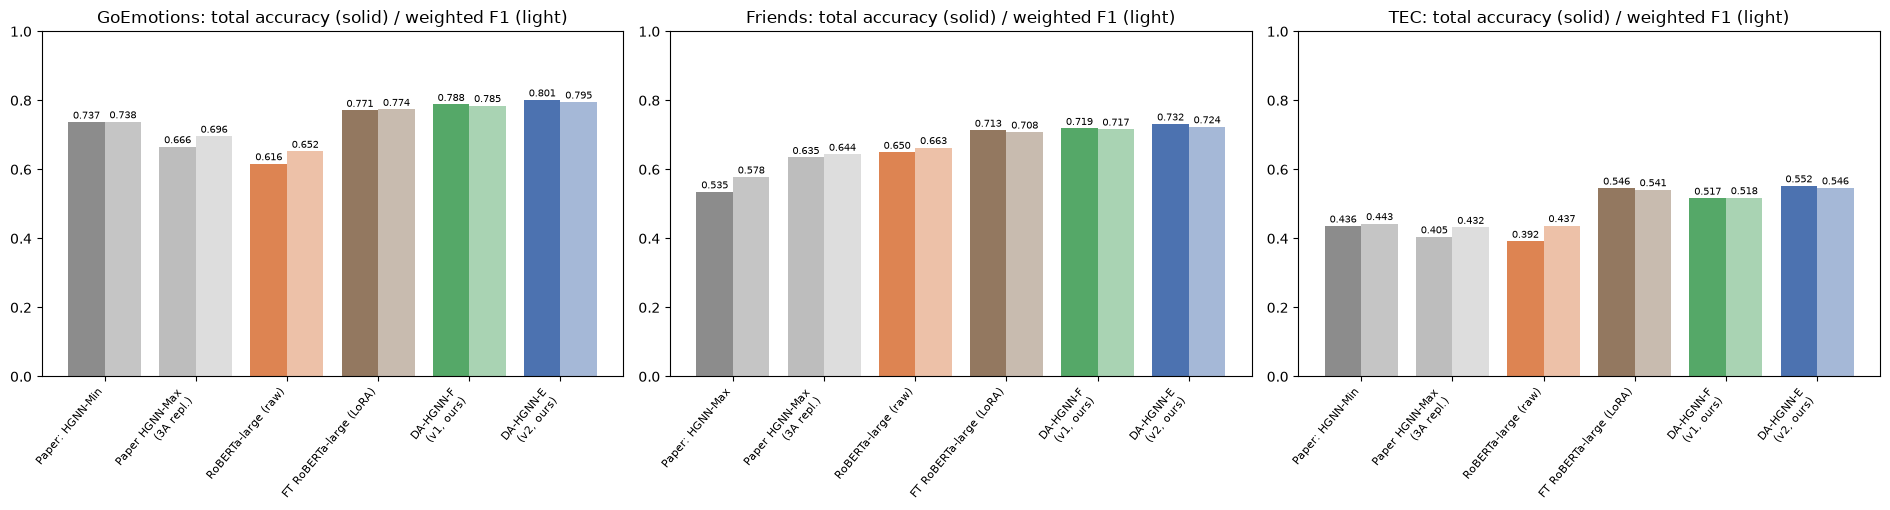

,dataset,system,acc_T,f1_T,gain vs paper (acc pts),gain vs paper (F1 pts)
0,GoEmotions,Paper reported: HGNN-Min,0.737,0.738,0.000,0.000
1,GoEmotions,Paper HGNN-Max (3A replication),0.666,0.696,-7.119,-4.178
2,GoEmotions,RoBERTa-large (raw),0.616,0.652,-12.056,-8.554
3,GoEmotions,FT RoBERTa-large (LoRA),0.771,0.774,3.409,3.586
4,GoEmotions,"DA-HGNN-F (v1, 3B)",0.788,0.785,5.128,4.707
5,GoEmotions,DA-HGNN-E (proposed v2),0.801,0.795,6.438,5.716
6,Friends,Paper reported: HGNN-Max,0.535,0.578,0.000,0.000
7,Friends,Paper HGNN-Max (3A replication),0.635,0.644,9.952,6.587
8,Friends,RoBERTa-large (raw),0.650,0.663,11.455,8.531
9,Friends,FT RoBERTa-large (LoRA),0.713,0.708,17.846,13.010


In [17]:
PAPER_BEST = {'GoEmotions': ('HGNN-Min', .737, .738), 'Friends': ('HGNN-Max', .535, .578), 'TEC': ('HGNN-Min', .436, .443)}
rows = []
for n in CFG['datasets']:
    rows.append(dict(dataset=n, system=f'Paper reported: {PAPER_BEST[n][0]}', acc_T=PAPER_BEST[n][1], f1_T=PAPER_BEST[n][2]))
    for mo in ('Paper HGNN-Max (3A replication)', 'RoBERTa-large (raw)', 'FT RoBERTa-large (LoRA)', 'DA-HGNN-F (v1, 3B)', 'DA-HGNN-E (proposed v2)'):
        x = TEST[(TEST.dataset == n) & (TEST.model == mo)][['acc_T', 'f1_T']].mean()
        rows.append(dict(dataset=n, system=mo, acc_T=x.acc_T, f1_T=x.f1_T))
VS2 = pd.DataFrame(rows)
VS2['gain vs paper (acc pts)'] = VS2.apply(lambda r: 100 * (r.acc_T - PAPER_BEST[r.dataset][1]), axis=1)
VS2['gain vs paper (F1 pts)'] = VS2.apply(lambda r: 100 * (r.f1_T - PAPER_BEST[r.dataset][2]), axis=1)
VS2.to_csv(os.path.join(V2_DIR, 'comparison_with_paper_v2.csv'), index=False)

fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))
cols = {'Paper reported': '#8C8C8C', 'Paper HGNN-Max (3A replication)': '#BDBDBD', 'RoBERTa-large (raw)': '#DD8452',
        'FT RoBERTa-large (LoRA)': '#937860', 'DA-HGNN-F (v1, 3B)': '#55A868', 'DA-HGNN-E (proposed v2)': '#4C72B0'}
for ax, n in zip(axes, CFG['datasets']):
    sub = VS2[VS2.dataset == n].reset_index(drop=True); x = np.arange(len(sub))
    c = [cols['Paper reported'] if s.startswith('Paper reported') else cols[s] for s in sub.system]
    ax.bar(x - 0.2, sub.acc_T, 0.4, color=c); ax.bar(x + 0.2, sub.f1_T, 0.4, color=c, alpha=0.5)
    for i, (a, f1) in enumerate(zip(sub.acc_T, sub.f1_T)):
        ax.text(i - 0.2, a + 0.01, f'{a:.3f}', ha='center', fontsize=7); ax.text(i + 0.2, f1 + 0.01, f'{f1:.3f}', ha='center', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels([s.replace('Paper reported: ', 'Paper: ').replace(' (3A replication)', '\n(3A repl.)').replace(' (proposed v2)', '\n(v2, ours)').replace(' (v1, 3B)', '\n(v1, ours)')
                                          for s in sub.system], rotation=50, ha='right', fontsize=8)
    ax.set_ylim(0, 1); ax.set_title(f'{n}: total accuracy (solid) / weighted F1 (light)')
plt.tight_layout(); plt.savefig(os.path.join(V2_DIR, 'fig_v2_comparison.png'), dpi=150, bbox_inches='tight'); plt.show()
VS2.round(3)

## 7. Conclusions (Phase 3C)

**Confirmatory test result.** Untouched 80% test split, 5 seeds, the same 500 labels for every method. Total accuracy / weighted F1:

| Dataset | Paper best HGNN (reported) | v1 DA-HGNN-F (3B) | **v2 DA-HGNN-E** | v2 − v1 (paired t) | **v2 − paper** |
|---|---|---|---|---|---|
| GoEmotions | .737 / .738 | .788 / .785 | **.801 / .795** | +1.3 / +1.0 (p = .002 / .02) | **+6.4 / +5.7** |
| Friends | .535 / .578 | .719 / .717 | **.732 / .724** | +1.3 / +0.7 (p = .002 / .05) | **+19.7 / +14.6** |
| TEC (unseen) | .436 / .443 | .517 / .518 | **.552 / .546** | +3.6 / +2.9 (p = .002 / .002) | **+11.6 / +10.4** |

* **The selection held up.** The selected ensemble scored 0.694 on the held-out pool and 0.692 on the test split, so choosing on held-out data did not overfit.
* **v2 is the best few-label system on GoEmotions and Friends, and tied-best on TEC.** Paired t-tests over 5 seeds:
  * vs v1: accuracy significantly better on all three datasets (p ≤ .002); F1 significant on GoEmotions and TEC, borderline on Friends (p = .051);
  * vs the calibrated teacher: significant on every dataset and metric;
  * vs fine-tuned RoBERTa-large: significant on GoEmotions and Friends; **tie on TEC** (+0.7 points, p = 0.36);
  * vs fine-tuned DistilRoBERTa: significant except GoEmotions accuracy (p = 0.07);
  * vs the supervised MLP: accuracy significant everywhere; F1 significant on TEC only (GoEmotions/Friends p = 0.06–0.07).
* **A strong new baseline.** Simply fine-tuning RoBERTa-large with LoRA on the 500 labels already beats the paper by +3.4 / +17.8 / +11.0 accuracy points. With a few labels, *what you train on* matters more than the architecture.

**Where the extra gain comes from** (leave-one-member-out on test; change in accuracy / F1 points when the member is removed):
* fine-tuned DistilRoBERTa −0.48 / −0.35, fine-tuned RoBERTa-large −0.31 / −0.35, supervised MLP −0.32 / −0.16: **these carry the gain**;
* DA-HGNN student +0.29 / +0.02, calibrated teacher +0.20 / +0.20: **within noise inside v2**.

*Honest reading:* once two fine-tuned LMs are in the ensemble, the graph student and the calibrated teacher no longer add measurable accuracy. Their value lies in v1, in the label-free and very-few-label regimes, and in robustness on the unseen TEC (3B).

**Negative / exploratory results**
* Correct & Smooth with gold labels: −7.6 points on the held-out pool, dropped.
* Self-training (Noisy Student) looked promising (+0.3 to +1.2 points on top of the 5-way ensemble, GoEmotions and Friends, 1 seed). It is too slow and crash-prone on a 6 GB laptop GPU to evaluate properly, so it is left as future work.

**Remaining headroom.** The oracle over the 5 members reaches 0.822 accuracy on held-out data vs 0.694 for the equal-weight vote. Next steps: a learned combiner (stacking with cross-fitting), self-training on stronger hardware, and active learning of which disagreed posts to label.